In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
HCP_CSV = Path("results/HCP/analysis/diff_maps/hcp_mae_snr_summary.csv")
LAB_CSV = Path("results/Lab/analysis/diff_maps/lab_mae_snr_summary.csv")
FIG_DIR = Path("results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────
try:
    plt.style.use("seaborn-v0_8-whitegrid")  # matplotlib >= 3.6
except OSError:
    plt.style.use("seaborn-whitegrid")        # matplotlib < 3.6 (Anaconda)
HCP_COLOR  = "#2166ac"   # blue  – random subsampling
LAB_COLOR  = "#d6604d"   # orange-red – optimized subsampling
HCP_STYLE  = dict(color=HCP_COLOR, linestyle="-",  marker="o", linewidth=1.8, markersize=5)
LAB_STYLE  = dict(color=LAB_COLOR, linestyle="--", marker="s", linewidth=1.8, markersize=5)
SHELLS     = [1000, 2000, 3000]
FONT_TITLE = 10
FONT_LABEL = 9
FONT_TICK  = 8

print(f"HCP CSV: {HCP_CSV}  exists={HCP_CSV.exists()}")
print(f"Lab CSV: {LAB_CSV}  exists={LAB_CSV.exists()}")
print(f"Figures → {FIG_DIR.resolve()}")

HCP CSV: results\HCP\analysis\diff_maps\hcp_mae_snr_summary.csv  exists=True
Lab CSV: results\Lab\analysis\diff_maps\lab_mae_snr_summary.csv  exists=True
Figures → D:\UofR\03 Uddin Lab\Codes_Data\results\figures


In [2]:
# ── Load & clean data ──────────────────────────────────────────────────────
hcp_raw = pd.read_csv(HCP_CSV)
lab_raw = pd.read_csv(LAB_CSV)

# Remove self-comparison reference rows (MAE == 0, SNR == inf)
hcp = hcp_raw[hcp_raw["FA_MAE"] > 0].copy()
lab = lab_raw[lab_raw["FA_MAE"] > 0].copy()

# Replace inf SNR with NaN for plotting
for df in (hcp, lab):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("HCP protocols:")
print(hcp[["protocol", "shell", "ndirs"]].to_string(index=False))
print("\nLab protocols:")
print(lab[["protocol", "shell", "ndirs"]].to_string(index=False))

HCP protocols:
 protocol  shell  ndirs
b1000_n20   1000     20
b1000_n30   1000     30
b1000_n45   1000     45
b1000_n60   1000     60
b1000_n75   1000     75
b2000_n20   2000     20
b2000_n30   2000     30
b2000_n45   2000     45
b2000_n60   2000     60
b2000_n75   2000     75
b3000_n20   3000     20
b3000_n30   3000     30
b3000_n45   3000     45
b3000_n60   3000     60
b3000_n75   3000     75

Lab protocols:
 protocol  shell  ndirs
b1000_n20   1000     20
b1000_n30   1000     30
b1000_n45   1000     45
b1000_n60   1000     60
b2000_n20   2000     20
b2000_n30   2000     30
b2000_n45   2000     45
b2000_n60   2000     60
b3000_n20   3000     20
b3000_n30   3000     30
b3000_n45   3000     45


## Figure 1 — DTI MAE vs Direction Count

C:\Users\HP\AppData\Local\Temp\ipykernel_24208\3630466552.py:32: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_24208\3630466552.py:34: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  plt.savefig(out, dpi=150, bbox_inches="tight")
e:\Anaconda\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


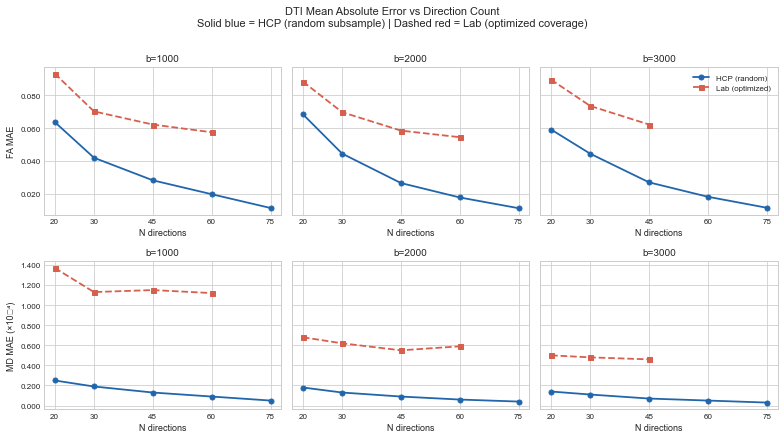

Saved: results\figures\fig1_dti_mae.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey="row")
fig.suptitle(
    "DTI Mean Absolute Error vs Direction Count\n"
    "Solid blue = HCP (random subsample) | Dashed red = Lab (optimized coverage)",
    fontsize=11, y=1.01
)

dti_metrics = [("FA_MAE", "FA MAE"), ("MD_MAE", "MD MAE (×10⁻⁴)")]

for row, (col, ylabel) in enumerate(dti_metrics):
    scale = 1e4 if col == "MD_MAE" else 1.0
    for col_idx, shell in enumerate(SHELLS):
        ax = axes[row, col_idx]

        h = hcp[hcp["shell"] == shell].sort_values("ndirs")
        l = lab[lab["shell"] == shell].sort_values("ndirs")

        ax.plot(h["ndirs"], h[col] * scale, label="HCP (random)", **HCP_STYLE)
        ax.plot(l["ndirs"], l[col] * scale, label="Lab (optimized)", **LAB_STYLE)

        ax.set_title(f"b={shell}", fontsize=FONT_TITLE)
        ax.set_xlabel("N directions", fontsize=FONT_LABEL)
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=FONT_LABEL)
        ax.tick_params(labelsize=FONT_TICK)
        ax.set_xticks(sorted(set(h["ndirs"].tolist() + l["ndirs"].tolist())))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))

        if row == 0 and col_idx == 2:
            ax.legend(fontsize=FONT_TICK, loc="upper right")

plt.tight_layout()
out = FIG_DIR / "fig1_dti_mae.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Figure 2 — NODDI NDI + ODI MAE vs Direction Count

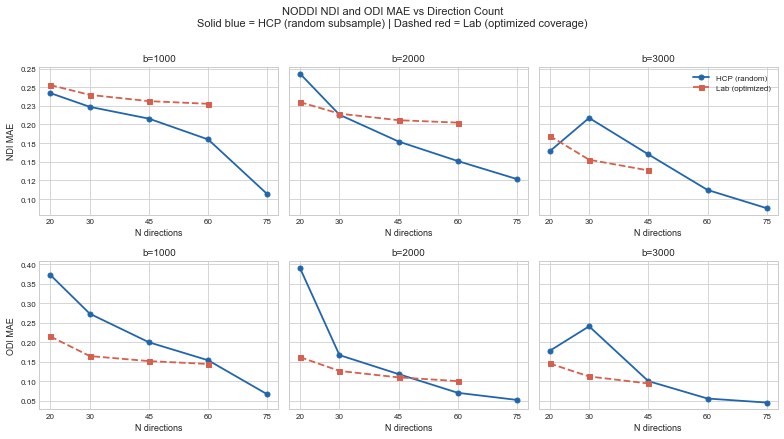

Saved: results\figures\fig2_noddi_ndi_odi_mae.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey="row")
fig.suptitle(
    "NODDI NDI and ODI MAE vs Direction Count\n"
    "Solid blue = HCP (random subsample) | Dashed red = Lab (optimized coverage)",
    fontsize=11, y=1.01
)

noddi_metrics = [("NDI_MAE", "NDI MAE"), ("ODI_MAE", "ODI MAE")]

for row, (col, ylabel) in enumerate(noddi_metrics):
    for col_idx, shell in enumerate(SHELLS):
        ax = axes[row, col_idx]

        h = hcp[hcp["shell"] == shell].sort_values("ndirs")
        l = lab[lab["shell"] == shell].sort_values("ndirs")

        ax.plot(h["ndirs"], h[col], label="HCP (random)", **HCP_STYLE)
        ax.plot(l["ndirs"], l[col], label="Lab (optimized)", **LAB_STYLE)

        ax.set_title(f"b={shell}", fontsize=FONT_TITLE)
        ax.set_xlabel("N directions", fontsize=FONT_LABEL)
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=FONT_LABEL)
        ax.tick_params(labelsize=FONT_TICK)
        ax.set_xticks(sorted(set(h["ndirs"].tolist() + l["ndirs"].tolist())))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

        if row == 0 and col_idx == 2:
            ax.legend(fontsize=FONT_TICK, loc="upper right")

plt.tight_layout()
out = FIG_DIR / "fig2_noddi_ndi_odi_mae.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Figure 3 — NODDI FWF MAE vs Direction Count
FWF is fundamentally unreliable in single-shell acquisitions regardless of direction count or sampling strategy.

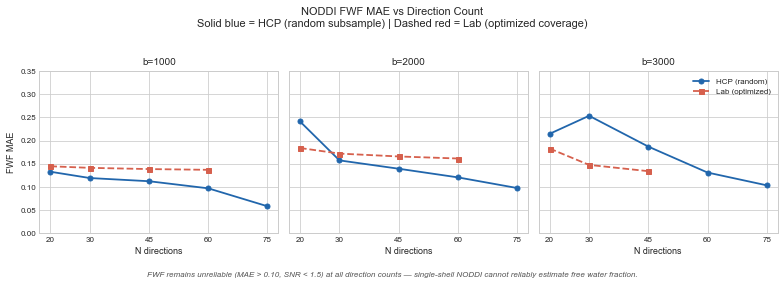

Saved: results\figures\fig3_fwf_mae.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)
fig.suptitle(
    "NODDI FWF MAE vs Direction Count\n"
    "Solid blue = HCP (random subsample) | Dashed red = Lab (optimized coverage)",
    fontsize=11, y=1.03
)

for col_idx, shell in enumerate(SHELLS):
    ax = axes[col_idx]

    h = hcp[hcp["shell"] == shell].sort_values("ndirs")
    l = lab[lab["shell"] == shell].sort_values("ndirs")

    ax.plot(h["ndirs"], h["FWF_MAE"], label="HCP (random)", **HCP_STYLE)
    ax.plot(l["ndirs"], l["FWF_MAE"], label="Lab (optimized)", **LAB_STYLE)

    ax.set_title(f"b={shell}", fontsize=FONT_TITLE)
    ax.set_xlabel("N directions", fontsize=FONT_LABEL)
    if col_idx == 0:
        ax.set_ylabel("FWF MAE", fontsize=FONT_LABEL)
    ax.tick_params(labelsize=FONT_TICK)
    ax.set_xticks(sorted(set(h["ndirs"].tolist() + l["ndirs"].tolist())))
    ax.set_ylim(0, 0.35)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

    if col_idx == 2:
        ax.legend(fontsize=FONT_TICK, loc="upper right")

fig.text(
    0.5, -0.04,
    "FWF remains unreliable (MAE > 0.10, SNR < 1.5) at all direction counts — "
    "single-shell NODDI cannot reliably estimate free water fraction.",
    ha="center", fontsize=8, style="italic", color="#555555"
)

plt.tight_layout()
out = FIG_DIR / "fig3_fwf_mae.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Figure 4 — % MAE Reduction n20 → n45 Summary
n45 is the highest direction count shared by **all shells in both datasets**, making it a fair cross-dataset comparison point.

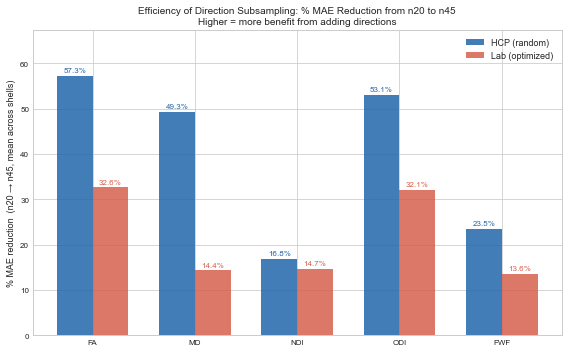

Saved: results\figures\fig4_pct_reduction_n20_n45.png


In [6]:
metrics_cols   = ["FA_MAE", "MD_MAE", "NDI_MAE", "ODI_MAE", "FWF_MAE"]
metrics_labels = ["FA", "MD", "NDI", "ODI", "FWF"]

def pct_reduction_n20_n45(df):
    """Mean % MAE reduction going from n20 to n45, averaged across 3 shells."""
    reductions = {m: [] for m in metrics_cols}
    for shell in SHELLS:
        sub = df[df["shell"] == shell]
        r20 = sub[sub["ndirs"] == 20].iloc[0]
        r45 = sub[sub["ndirs"] == 45].iloc[0]
        for m in metrics_cols:
            if r20[m] > 0:
                reductions[m].append((r20[m] - r45[m]) / r20[m] * 100)
    return {m: np.mean(v) for m, v in reductions.items()}

hcp_pct = pct_reduction_n20_n45(hcp)
lab_pct = pct_reduction_n20_n45(lab)

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_hcp = ax.bar(x - width/2, [hcp_pct[m] for m in metrics_cols], width,
                  label="HCP (random)",    color=HCP_COLOR, alpha=0.85)
bars_lab = ax.bar(x + width/2, [lab_pct[m] for m in metrics_cols], width,
                  label="Lab (optimized)", color=LAB_COLOR, alpha=0.85)

for bar in bars_hcp:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color=HCP_COLOR)
for bar in bars_lab:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color=LAB_COLOR)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=FONT_LABEL)
ax.set_ylabel("% MAE reduction  (n20 → n45, mean across shells)", fontsize=FONT_LABEL)
ax.set_title(
    "Efficiency of Direction Subsampling: % MAE Reduction from n20 to n45\n"
    "Higher = more benefit from adding directions",
    fontsize=FONT_TITLE
)
ax.legend(fontsize=FONT_LABEL)
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout()
out = FIG_DIR / "fig4_pct_reduction_n20_n45.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Figure 5 — Subsampling SNR vs Direction Count
SNR = mean(reference) / std(diff). Higher = subsampled protocol closer to reference.  
Note MD SNR uses a log scale — HCP MD SNR reaches 148 vs Lab's ceiling of ~7 due to acquisition noise floor.

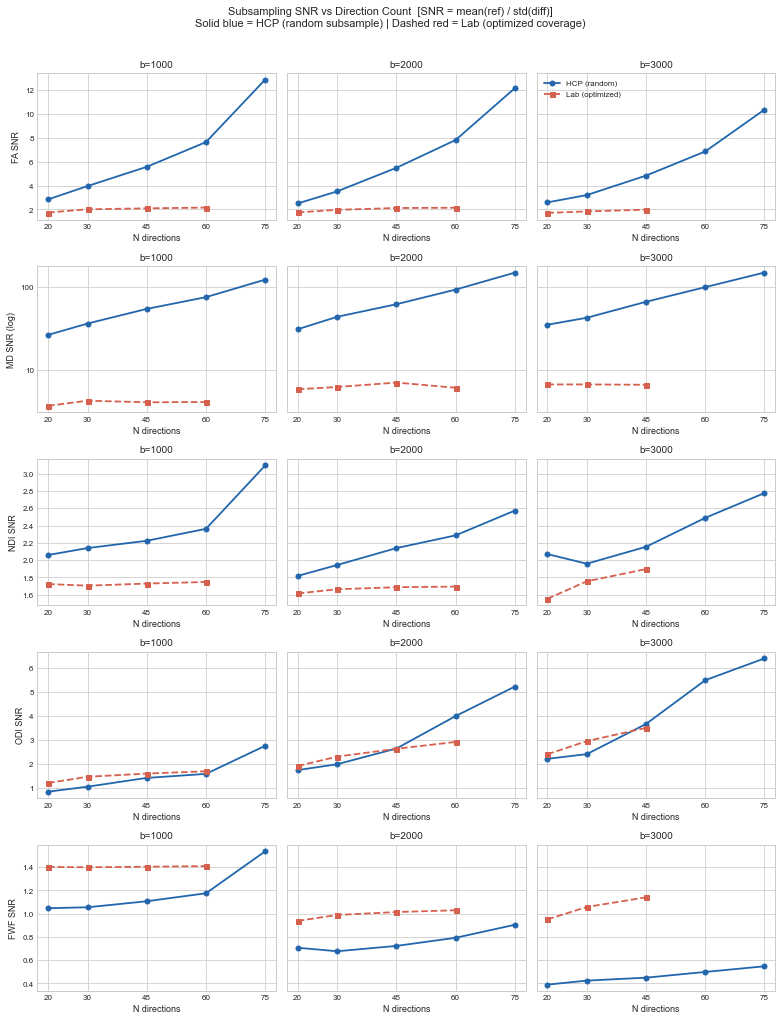

Saved: results\figures\fig5_snr.png


In [7]:
snr_metrics = [
    ("FA_SNR",  "FA SNR",        False),
    ("MD_SNR",  "MD SNR (log)",  True),
    ("NDI_SNR", "NDI SNR",       False),
    ("ODI_SNR", "ODI SNR",       False),
    ("FWF_SNR", "FWF SNR",       False),
]

fig, axes = plt.subplots(5, 3, figsize=(11, 14), sharey="row")
fig.suptitle(
    "Subsampling SNR vs Direction Count  [SNR = mean(ref) / std(diff)]\n"
    "Solid blue = HCP (random subsample) | Dashed red = Lab (optimized coverage)",
    fontsize=11, y=1.01
)

for row, (col, ylabel, use_log) in enumerate(snr_metrics):
    for col_idx, shell in enumerate(SHELLS):
        ax = axes[row, col_idx]

        h = hcp[hcp["shell"] == shell].sort_values("ndirs")
        l = lab[lab["shell"] == shell].sort_values("ndirs")

        ax.plot(h["ndirs"], h[col], label="HCP (random)", **HCP_STYLE)
        ax.plot(l["ndirs"], l[col], label="Lab (optimized)", **LAB_STYLE)

        if use_log:
            ax.set_yscale("log")
            ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

        ax.set_title(f"b={shell}", fontsize=FONT_TITLE)
        ax.set_xlabel("N directions", fontsize=FONT_LABEL)
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=FONT_LABEL)
        ax.tick_params(labelsize=FONT_TICK)
        ax.set_xticks(sorted(set(h["ndirs"].tolist() + l["ndirs"].tolist())))

        if row == 0 and col_idx == 2:
            ax.legend(fontsize=FONT_TICK, loc="upper left")

plt.tight_layout()
out = FIG_DIR / "fig5_snr.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

In [8]:
# ── Summary ────────────────────────────────────────────────────────────────
saved = sorted(FIG_DIR.glob("fig*.png"))
print(f"All figures saved to: {FIG_DIR.resolve()}\n")
for f in saved:
    print(f"  {f.name}")

All figures saved to: D:\UofR\03 Uddin Lab\Codes_Data\results\figures

  fig1_dti_mae.png
  fig2_noddi_ndi_odi_mae.png
  fig3_fwf_mae.png
  fig4_pct_reduction_n20_n45.png
  fig5_snr.png
